In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, auc

## 2. Carga y exploración de datos

In [2]:
df = pd.read_csv("../data/data.csv")
df = df.drop(columns = ['date'])
df

,precipitation,temp_max,temp_min,wind,weather
0,0.0,12.8,5.0,4.7,drizzle
1,10.9,10.6,2.8,4.5,rain
2,0.8,11.7,7.2,2.3,rain
3,20.3,12.2,5.6,4.7,rain
4,1.3,8.9,2.8,6.1,rain
...,...,...,...,...,...
1456,8.6,4.4,1.7,2.9,rain
1457,1.5,5.0,1.7,1.3,rain
1458,0.0,7.2,0.6,2.6,fog
1459,0.0,5.6,-1.0,3.4,sun


In [3]:
X =  df.drop('weather', axis = 1, errors='ignore')
Y = df['weather']

In [4]:

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)

ros = RandomOverSampler(random_state=42)
X_train_balanced, Y_train_balanced = ros.fit_resample(X_train, Y_train)
Counter(Y_train_balanced)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13],
    'weights': ['uniform', 'distance'],
    'p' : [1, 2],
    'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute']
}

In [7]:
grid_search = GridSearchCV(estimator = knn, param_grid = param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1, verbose = 1)
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_
print("Best Hyperparameters: ", grid_search.best_params_)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best Hyperparameters:  {'algorithm': 'auto', 'n_neighbors': 11, 'p': 1, 'weights': 'distance'}


C:\Users\hugo_\Documents\GitHub\TC2004B-Hugo\tc2004b_env\Lib\site-packages\sklearn\model_selection\_search.py:1137: UserWarning: One or more of the test scores are non-finite: [0.69963176 0.71919656 0.69865615 0.71724055 0.73585366 0.73779053
 0.72409374 0.73289813 0.75148733 0.74953611 0.72406504 0.73191296
 0.74756576 0.7505165  0.73679101 0.73875179 0.7514682  0.75931133
 0.7367671  0.74364419 0.74658058 0.7554089  0.73285509 0.7397274
 0.70061215 0.72017695 0.69963654 0.71822095 0.73585366 0.73779053
 0.72409374 0.73289813 0.75148733 0.74953611 0.72406504 0.73191296
 0.74756576 0.7505165  0.73679101 0.73875179 0.7514682  0.75931133
 0.7367671  0.74364419 0.74658058 0.7554089  0.73285509 0.7397274
 0.69963176 0.71919656 0.69865615 0.71724055 0.73585366 0.73779053
 0.72409374 0.73289813 0.75148733 0.74953611 0.72406504 0.73191296
 0.74756576 0.7505165  0.73679101 0.73875179 0.7514682  0.75931133
 0.7367671  0.74364419 0.74658058 0.7554089  0.73285509 0.7397274
        nan 0.72017695 

In [8]:
y_pred = best_model.predict(X_test_scaled)

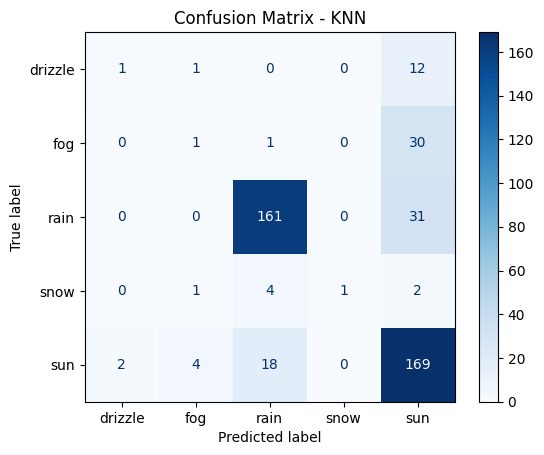

In [9]:
cm = confusion_matrix(y_test, y_pred, labels = best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = best_model.classes_)
disp.plot(cmap = plt.cm.Blues)
plt.title("Confusion Matrix - KNN")
plt.show()

In [10]:
report = classification_report(y_test, y_pred, labels = best_model.classes_)
print("Classification Report: ")
print(report)

Classification Report: 
              precision    recall  f1-score   support

     drizzle       0.33      0.07      0.12        14
         fog       0.14      0.03      0.05        32
        rain       0.88      0.84      0.86       192
        snow       1.00      0.12      0.22         8
         sun       0.69      0.88      0.77       193

    accuracy                           0.76       439
   macro avg       0.61      0.39      0.40       439
weighted avg       0.73      0.76      0.73       439

